# EDA - Claims & Frequency

In [21]:
from statistics import variance

import statsmodels
from databricks.connect import DatabricksSession
from pyspark.sql import functions
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
spark = DatabricksSession.builder.getOrCreate()

In [2]:
CATALOG = "commercial-insurance-underwriting-solution-catalog"
SEED = 42
policy = spark.table(f"`{CATALOG}`.silver.policy")

## Exploring the Policy dataset

- Each id tracked to see how many years it has been used - signalling renewal since new business?

In [4]:
policy_year_per_id = policy.groupBy('ID').count().withColumnRenamed('count', 'number_of_year_of_policy')
policy_year_per_id.groupBy('number_of_year_of_policy').count().withColumnRenamed('count', 'n_policy').orderBy('number_of_year_of_policy').show()

I0902 21:12:06.029211 2091383 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(91, generation: 1)


+------------------------+--------+
|number_of_year_of_policy|n_policy|
+------------------------+--------+
|                       1|   20579|
|                       2|   14685|
|                       3|   17346|
|                       4|     892|
+------------------------+--------+



- An example to trace

In [5]:
example_id = policy_year_per_id.filter('number_of_year_of_policy == 4').first()['ID']
policy.filter(functions.col("ID") == example_id).orderBy("Date_last_renewal").select(
      "ID", "Date_start_contract", "Date_last_renewal", "Date_next_renewal",
      "Premium", "Cost_claims_year", "N_claims_year", "Type_risk", "Area", "Power",
  ).show(truncate=False)

+---+-------------------+-----------------+-----------------+-------+----------------+-------------+---------+----+-----+
|ID |Date_start_contract|Date_last_renewal|Date_next_renewal|Premium|Cost_claims_year|N_claims_year|Type_risk|Area|Power|
+---+-------------------+-----------------+-----------------+-------+----------------+-------------+---------+----+-----+
|1  |2015-11-05         |2015-11-05       |2016-11-05       |222.52 |0.0             |0            |1        |0   |80   |
|1  |2015-11-05         |2016-11-05       |2017-11-05       |213.78 |0.0             |0            |1        |0   |80   |
|1  |2015-11-05         |2017-11-05       |2018-11-05       |214.84 |0.0             |0            |1        |0   |80   |
|1  |2015-11-05         |2018-11-05       |2019-11-05       |216.99 |0.0             |0            |1        |0   |80   |
+---+-------------------+-----------------+-----------------+-------+----------------+-------------+---------+----+-----+



- Does each policy since new business line up year after year before churn?

In [6]:
w = Window.partitionBy('ID').orderBy('Date_last_renewal')
chained_policies = policy.withColumn('previous_next_renewal', functions.lag('Date_next_renewal').over(w)).withColumn('row_number', functions.row_number().over(w))
chained_policies.filter(functions.col('row_number') > 1).withColumn('chains_correctly', functions.col('Date_last_renewal') ==  functions.col('previous_next_renewal')).groupBy('chains_correctly').count().show()

+----------------+-----+
|chains_correctly|count|
+----------------+-----+
|            true|52053|
+----------------+-----+



- Lets look up the key target variables distribution
- We have confirmed that the n_claims_year for each row is all 1 year. this makes it the frequency meet the definition `claims_count/exposure`. Here the N_claims_count is the claims count the exposure is one year. N_claims_count will be renamed `Frequency`
- `Cost_claims_year` is the pure premium/total loss cost. Severity is defined as `Loss/claims_count`. As such severity will be calculated as ``

## Drilling into the Claims frequency

In [3]:
freq_severity = (
    policy
    .select('ID', 'N_claims_year', 'Cost_claims_year')
    .withColumn(
        'Severity',
        functions.when(functions.col('N_claims_year')>0,
        functions.col('Cost_claims_year')/functions.col('N_claims_year')
        )
    )
    .withColumnRenamed('N_claims_year', 'Frequency')
).toPandas()

I0904 17:25:17.118922 3241861 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(93, generation: 1)


In [7]:
frequency = freq_severity['Frequency']
frequency.describe()

count    105555.000000
mean          0.394695
std           1.105018
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          25.000000
Name: Frequency, dtype: float64

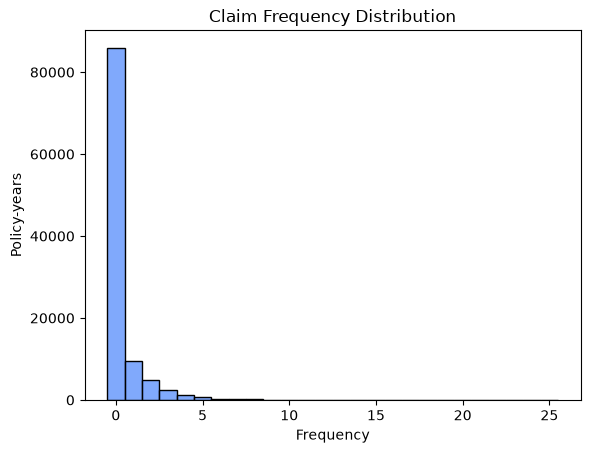

In [8]:
sns.histplot(frequency, discrete=True)
plt.xlabel('Frequency')
plt.ylabel('Policy-years')
plt.title(f'Claim Frequency Distribution')
plt.show()

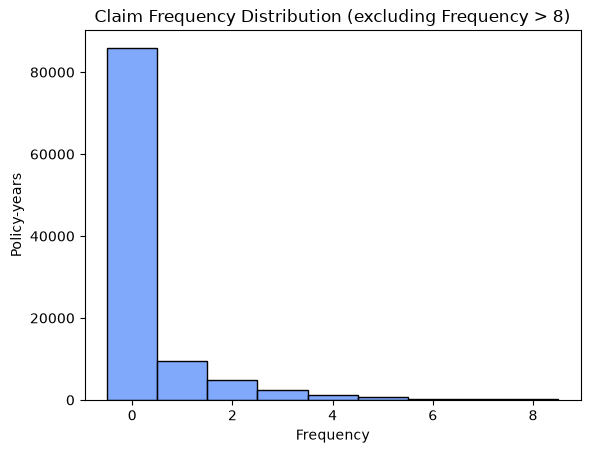

In [9]:
threshold = 8
tail = freq_severity[freq_severity['Frequency'] > threshold].sort_values('Frequency', ascending=False)
plot_data = freq_severity[freq_severity['Frequency'] <= threshold]
sns.histplot(plot_data['Frequency'], discrete=True)
plt.xlabel('Frequency')
plt.ylabel('Policy-years')
plt.title(f'Claim Frequency Distribution (excluding Frequency > {threshold})')
plt.show()
# print(f"tail: {tail}")

- The histogram above reveals that the claims frequency is zero-inflated and is right skewed following the poisson distrubtion. I will be running a few checks to confirm that poisson assumptions are met. i.e mean is approx equal the variance. There are few ways to do this.

In [10]:
# Method 1 - Using dispersion ratio - this is the smoke detector that suggest that if > 1 overdispersion needs to be drilled in
mean_f = frequency.mean()
var_f = frequency.var()
dispersion_ratio = var_f/mean_f
print(f"dispersion_ratio: {dispersion_ratio:.4f}")

dispersion_ratio: 3.0937


In [11]:
## Method 2: Fit a poisson model using a dummy exposure + calculate the pearson residual -> square it up and sum it to produce the pearson chi-square statistic. Divide the pearson statistic by degrees of freedom. If the poisson assumption that variance = mean then the output (squared standardised residual) should average out to 1. In this case the claims frequency has 3x more variance than poisson accounts for. Note - this does not mean that frequency fit to feature will give the same output.
import statsmodels.api as sm
import statsmodels.formula.api as smf
poisson_model = smf.glm('frequency ~ 1', data=frequency, family=sm.families.Poisson()).fit()
pearson_chi2 = poisson_model.pearson_chi2
dof = poisson_model.df_resid
print(f"Pearson chi2 / dof: {pearson_chi2/dof:.3f}")

Pearson chi2 / dof: 3.094


In [12]:
## Lets compare the zeros in the dataset to what we would expect from a poisson generation process. As in this case we see a 14percentage point more zeros in the dataset that the poisson implied process

import numpy as np
n = len(frequency)
observed_p0 = (frequency == 0).mean()
poisson_implied_p0 = np.exp(-mean_f)

print(f"Observed P(0): {observed_p0:.4f}")
print(f"Poisson-implied P(0): {poisson_implied_p0:.4f}")
print(f"Excess zeros: {observed_p0 - poisson_implied_p0:.4f}")

Observed P(0): 0.8139
Poisson-implied P(0): 0.6739
Excess zeros: 0.1400


- The distribution is right-skewed with a large zero mass (~86% of policy-years), consistent with a low-mean count process. n=[X] policies exceed a Frequency of 8, with a maximum of [25] -  flagged for investigation as potential outliers/data quality issues before modelling.
- Mean frequency = [x], variance = [y], giving a dispersion ratio of 3.094.variance substantially exceeds mean, violating the Poisson equidispersion assumption.Fitting an intercept-only Poisson GLM cross-confirms this via Pearson χ²/dof (≈3.0), consistent with the ratio above.
- Observed zero proportion (81.4%) substantially exceeds the Poisson-implied zero proportion (67.4%) given the fitted mean — an excess of 14 percentage points.
- This shows two distinct violations of the Poisson assumption: general overdispersion (unobserved heterogeneity across policies) and excess-zero mechanism. This jointly motivates prioritizing Zero-Inflated Negative Binomial (ZINB) as a leading algorithm candidate that handles both violations simultaneously

In [18]:
## Lets look at a contingent table for claims frequency  & then a correlation matrix as well
policy_df = policy.toPandas()

In [29]:
distribution_channel_map = {0: 'Agent', 1: 'Insurance Broker'}
payment_map = {0: 'Annual', 1: 'Half-yearly'}
type_risk_map = {1: 'Motorbike', 2: 'Van', 3: 'Passenger Car', 4: 'Agricultural Vehicle'}
area_map = {0: 'Rural', 1: 'Urban'}
second_driver_map = {0: 'Single Driver', 1: 'Multiple Drivers'}

policy_df['Distribution_channel_lbl'] = policy_df['Distribution_channel'].map(distribution_channel_map)
policy_df['Payment_lbl'] = policy_df['Payment'].map(payment_map)
policy_df['Type_risk_lbl'] = policy_df['Type_risk'].map(type_risk_map)
policy_df['Area_lbl'] = policy_df['Area'].map(area_map)
policy_df['Second_driver_lbl'] = policy_df['Second_driver'].map(second_driver_map)

policy_df['Claims_Frequency_binned'] = pd.cut(
    policy_df['N_claims_year'],
    bins=[-1, 0, 1, 2, 3, np.inf],
    labels=['0', '1', '2', '3', '4+']
)

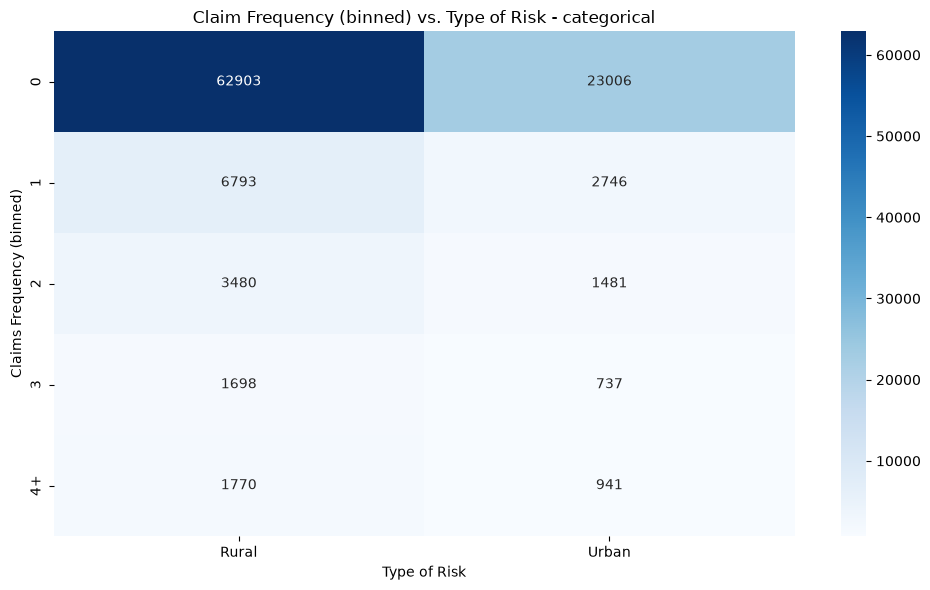

In [31]:
category = 'Area_lbl'
contingency = pd.crosstab(policy_df['Claims_Frequency_binned'], policy_df[category])
plt.figure(figsize=(10, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues')
plt.title('Claim Frequency (binned) vs. Type of Risk - categorical')
plt.xlabel('Type of Risk')
plt.ylabel('Claims Frequency (binned)')
plt.tight_layout()
plt.show()

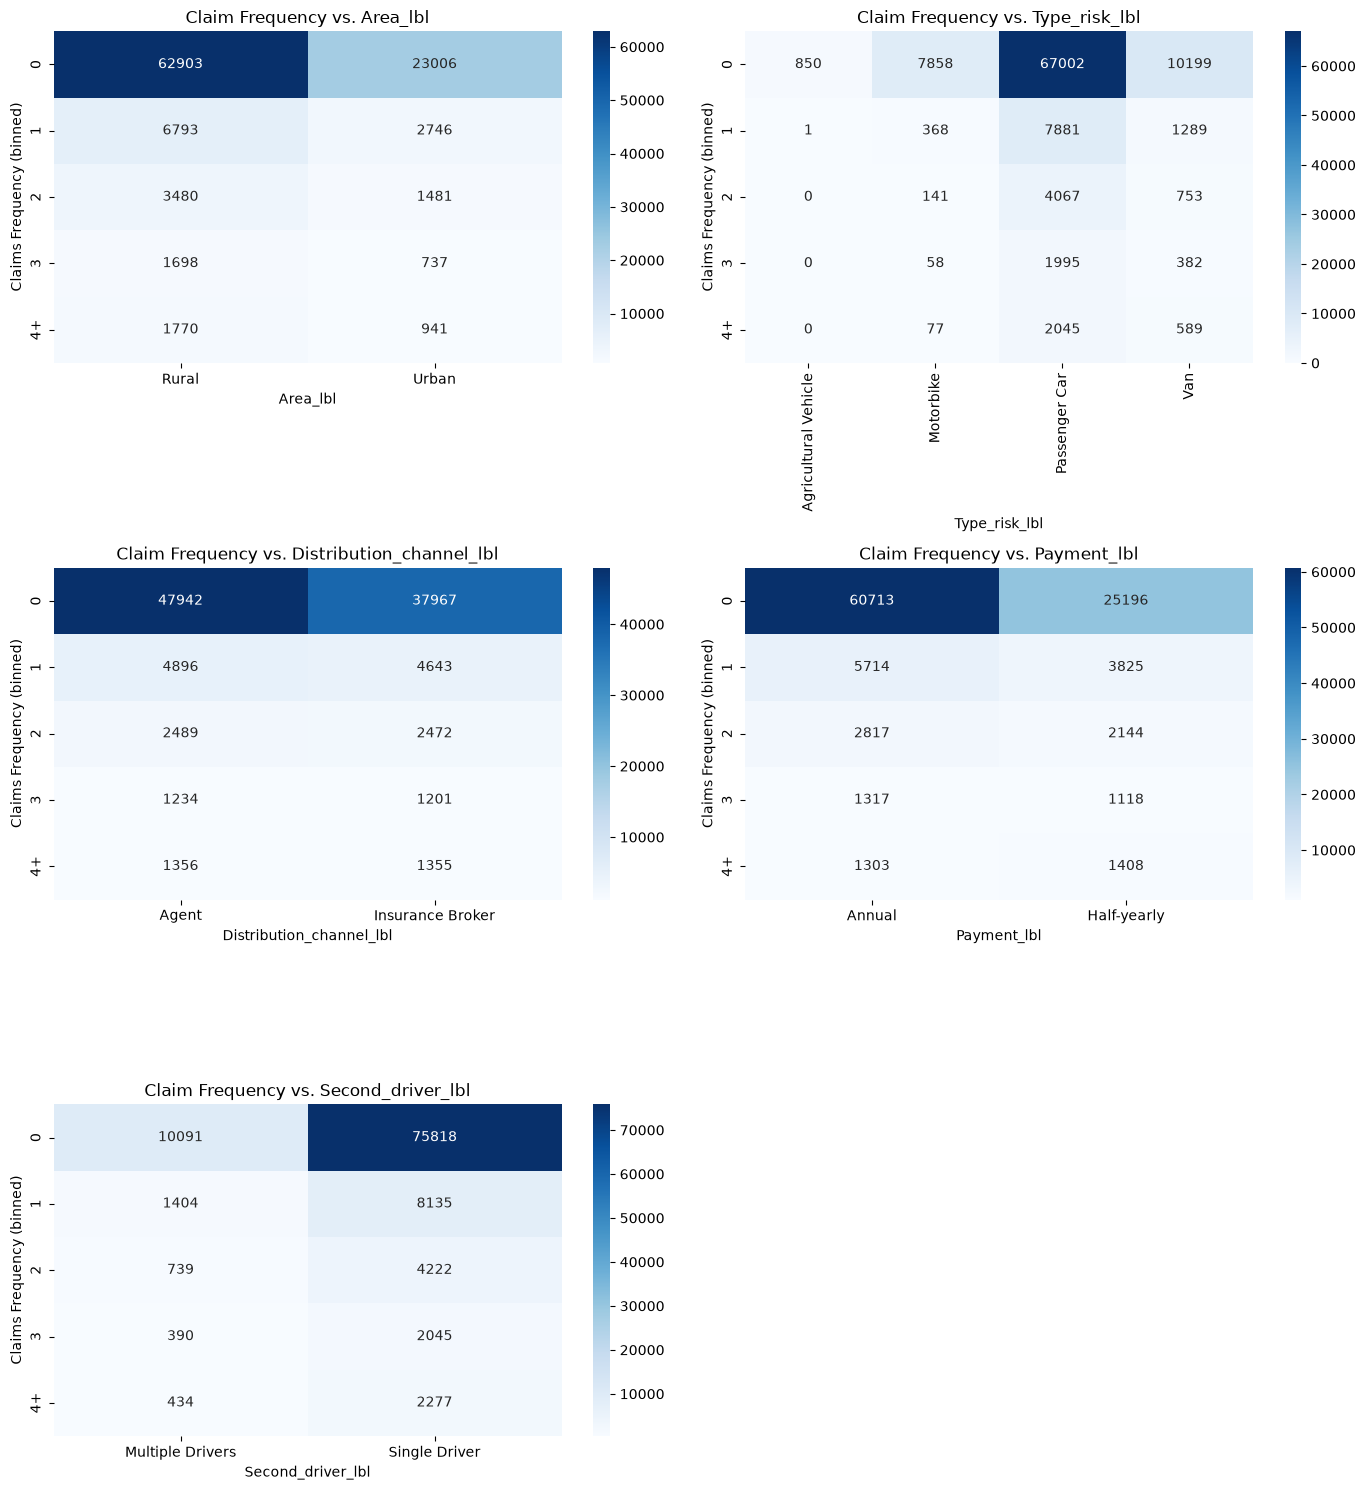

In [32]:
categories = ['Area_lbl', 'Type_risk_lbl', 'Distribution_channel_lbl',
              'Payment_lbl', 'Second_driver_lbl']

n_cols = 2
n_rows = int(np.ceil(len(categories) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()  # so we can index it flatly regardless of grid shape

for i, category in enumerate(categories):
    contingency = pd.crosstab(policy_df['Claims_Frequency_binned'], policy_df[category])

    sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=True)
    axes[i].set_title(f'Claim Frequency vs. {category}')
    axes[i].set_xlabel(category)
    axes[i].set_ylabel('Claims Frequency (binned)')

# hide any unused subplot axes if categories doesn't evenly fill the grid
for j in range(len(categories), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

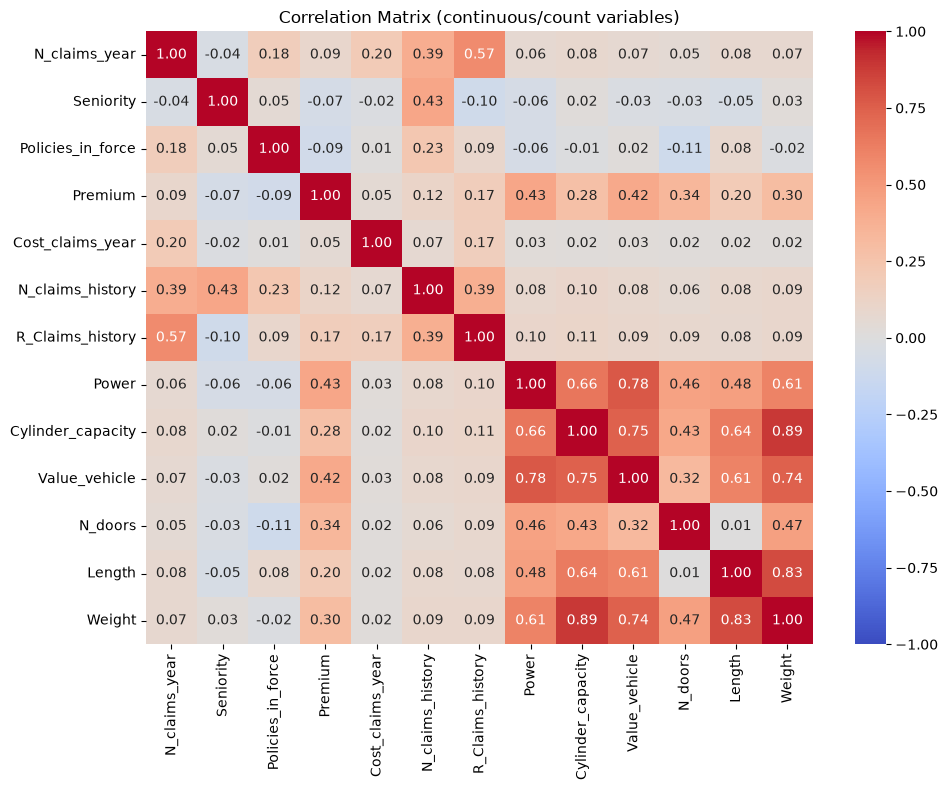

In [33]:
numeric_for_corr = [
    'N_claims_year', 'Seniority', 'Policies_in_force', 'Premium',
    'Cost_claims_year', 'N_claims_history', 'R_Claims_history',
    'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Length', 'Weight'
]

corr_matrix = policy_df[numeric_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (continuous/count variables)')
plt.tight_layout()
plt.show()

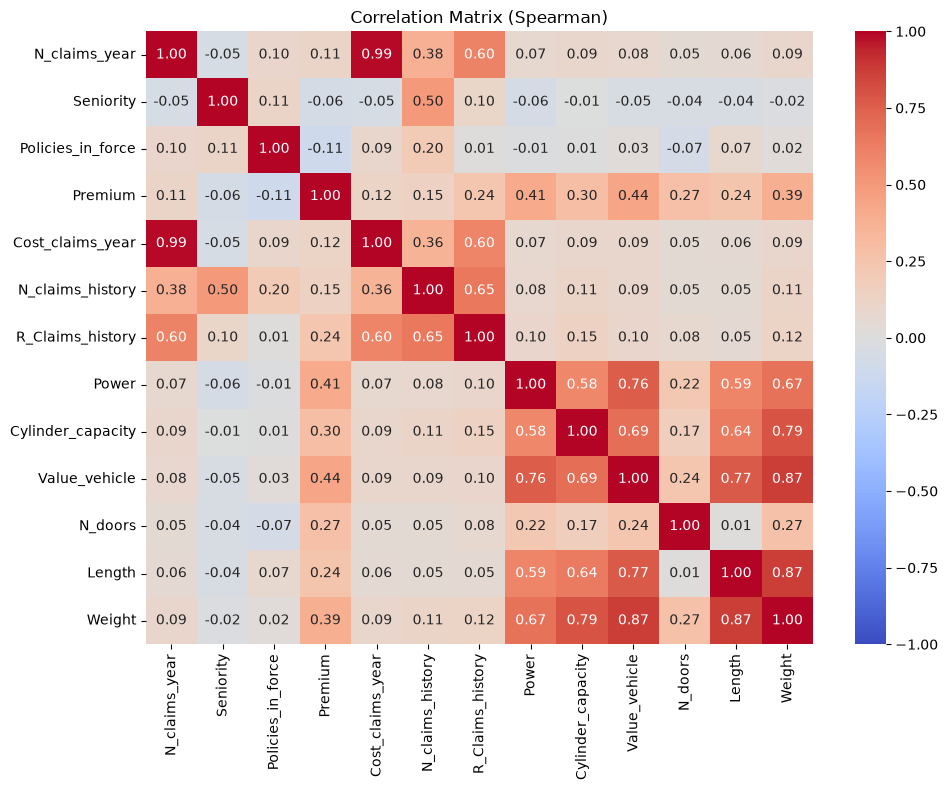

In [34]:
corr_matrix_spearman = policy_df[numeric_for_corr].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Spearman)')
plt.tight_layout()
plt.show()

## Drilling into Claims Severity

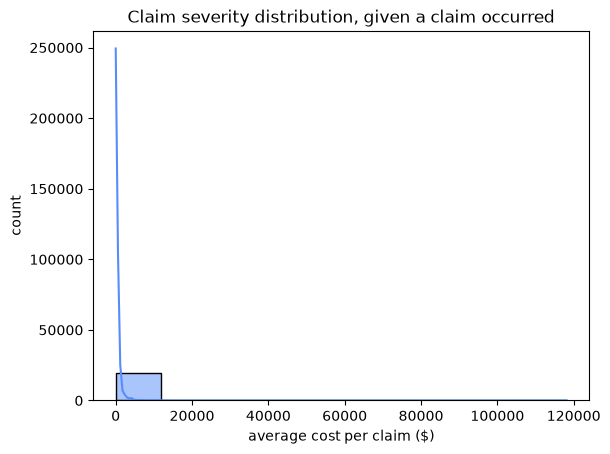

In [18]:
severity = freq_severity["Severity"].dropna()
sns.histplot(severity, bins=10, kde=True)
plt.xlabel('average cost per claim ($)')
plt.ylabel('count')
plt.title('Claim severity distribution, given a claim occurred')
plt.show()

In [14]:
severity.describe()

count     19646.000000
mean        467.096236
std        1568.012175
min           4.006923
25%          64.460000
50%         154.230000
75%         474.555000
max      118142.590000
Name: Severity, dtype: float64

## Drilling into Loss Cost/Pure Premium